<a href="https://colab.research.google.com/github/KaustubhSN12/TSA_Fitted_Curve/blob/main/Exponential_Smoothing_TSA_Practical_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Practical 9.	Forecasting by exponential smoothing**

<ipython-input-1-eb0d0d6282b5>:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_range = pd.date_range(start="2020-01-01", periods=50, freq="M")


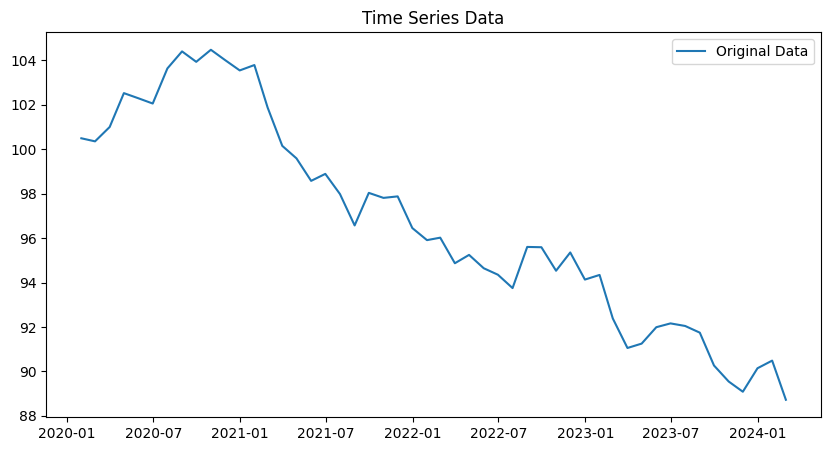

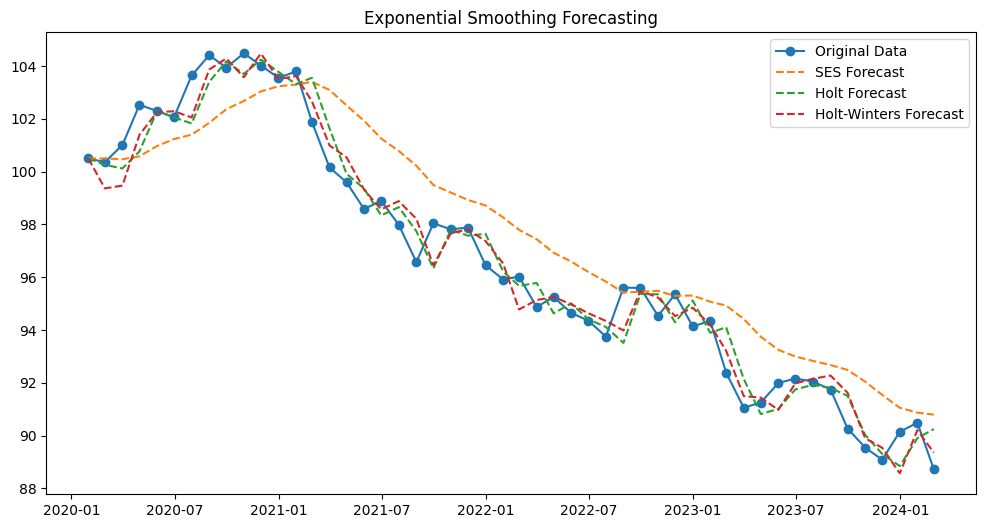

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# Generate synthetic time series data
np.random.seed(42)
date_range = pd.date_range(start="2020-01-01", periods=50, freq="M")
data = np.cumsum(np.random.randn(50)) + 100  # Random walk with drift
df = pd.DataFrame(data, index=date_range, columns=["Value"])

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(df, label="Original Data")
plt.title("Time Series Data")
plt.legend()
plt.show()

# Apply Simple Exponential Smoothing (SES)
model_ses = SimpleExpSmoothing(df["Value"]).fit(smoothing_level=0.2, optimized=False)
df["SES_Forecast"] = model_ses.fittedvalues

# Apply Double Exponential Smoothing (Holt’s Method)
model_holt = ExponentialSmoothing(df["Value"], trend="add").fit()
df["Holt_Forecast"] = model_holt.fittedvalues

# Apply Triple Exponential Smoothing (Holt-Winters Method)
model_holt_winters = ExponentialSmoothing(df["Value"], trend="add", seasonal="add", seasonal_periods=12).fit()
df["Holt_Winters_Forecast"] = model_holt_winters.fittedvalues

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(df["Value"], label="Original Data", marker="o")
plt.plot(df["SES_Forecast"], label="SES Forecast", linestyle="--")
plt.plot(df["Holt_Forecast"], label="Holt Forecast", linestyle="--")
plt.plot(df["Holt_Winters_Forecast"], label="Holt-Winters Forecast", linestyle="--")
plt.title("Exponential Smoothing Forecasting")
plt.legend()
plt.show()
